In [5]:
import numpy as np
from datetime import datetime
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.ticker import LogFormatterMathtext
import warnings
warnings.filterwarnings('ignore')
import get_manobs_soundings_pr_df
import kin1d_functions



In [6]:
file_soundings = ['upperair.sounding.202202222000.UQAM-Sorel.txt','upperair.sounding.202202222200.UQAM-Sorel.txt',\
                  'upperair.sounding.202202230000.UQAM-Sorel.txt', 'upperair.sounding.202202230200.UQAM-Sorel.txt',\
                      'upperair.sounding.202202230415.UQAM-Sorel.txt']
path = '/home/rml000/sitestore8/UQAM/projet_margaux/Pour_Mathieu_fig4/soundings_wintremix/'
dfs_sounding = []
for file in file_soundings:
    print(file)
    dfs_sounding.append(get_manobs_soundings_pr_df.read_soundings_data(path + file)[:1000])

dfs_sounding[4].loc[:,'RelHum'] = np.minimum(dfs_sounding[4].loc[:,'RelHum']+(100.-dfs_sounding[4].loc[200:400,'RelHum'].mean()), 100.)


upperair.sounding.202202222000.UQAM-Sorel.txt
upperair.sounding.202202222200.UQAM-Sorel.txt
upperair.sounding.202202230000.UQAM-Sorel.txt
upperair.sounding.202202230200.UQAM-Sorel.txt
upperair.sounding.202202230415.UQAM-Sorel.txt


# IOP5 Sorel

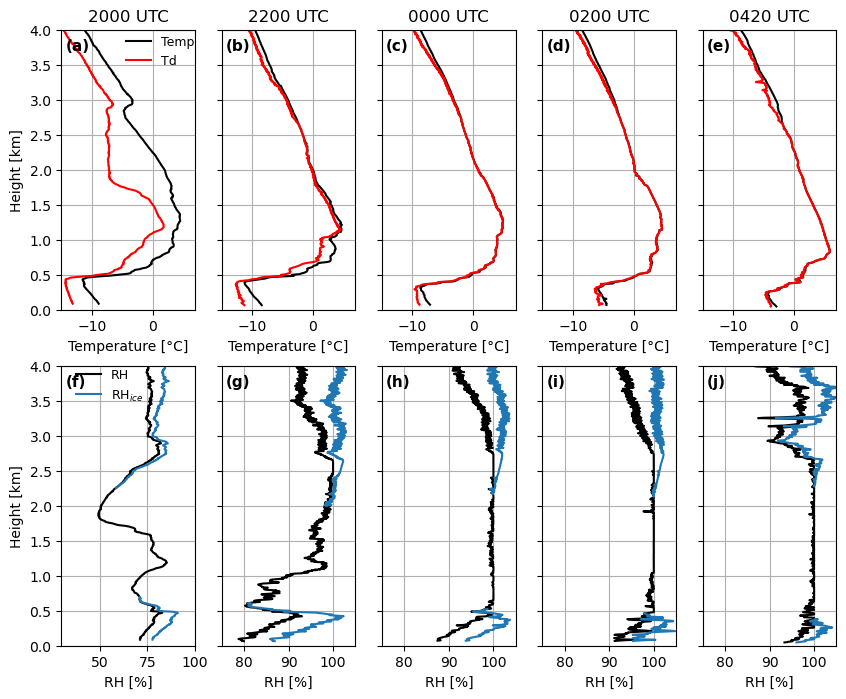

In [8]:
fig,axs= plt.subplots(2,5,figsize=(10,8))

ax = axs[0,:]

ind_first = 10

for i in range(5):
    ax[i].plot(dfs_sounding[i].Temp[ind_first:],dfs_sounding[i].height[ind_first:]/1000.,color='k')
    to_plot = np.array([kin1d_functions.dewpoint_from_rh(dfs_sounding[i].iloc[j].Temp+273.15,dfs_sounding[i].iloc[j].RelHum/100.,) for j in range(len(dfs_sounding[i].Temp)) ])
    ax[i].plot(to_plot[ind_first:] - 273.15,dfs_sounding[i].height[ind_first:]/1000.,color='red')

ax[0].plot(1,1,color='k',label='Temp')
ax[0].plot(1,1,color='red',label='Td')

ax[0].legend(frameon=False,bbox_to_anchor=(0.4, 1.02), fontsize=9)


for i in np.arange(1,5):
    ax[i].set_yticklabels(['','','','','','','','','','',''])
    ax[i].set_ylabel('')
    
titles = ['2000 UTC','2200 UTC','0000 UTC','0200 UTC','0420 UTC']
for i in range(5):
    ax[i].set_ylim([0,4])
    ax[i].set_xlim([-15,7])
    ax[i].grid('on')
    ax[i].set_xlabel('Temperature [°C]')
    
    ax[i].set_title(titles[i])
    
ax[0].set_ylabel('Height [km]')



ax2 = axs[1,:]
for i in range(5):
    ax2[i].plot(dfs_sounding[i].RelHum[ind_first:],dfs_sounding[i].height[ind_first:]/1000.,color='k')
    to_plot = np.array([100.*kin1d_functions.rh_to_ice(dfs_sounding[i].iloc[j].RelHum/100., dfs_sounding[i].iloc[j].Temp+273.15) for j in range(len(dfs_sounding[i].Temp)) ])
    ax2[i].plot(to_plot[ind_first:],dfs_sounding[i].height[ind_first:]/1000.,color='C0')

ax2[0].plot(1,1,color='k',label='RH')
ax2[0].plot(1,1,color='C0',label=r'RH$_{ice}$')

ax2[0].legend(frameon=False,bbox_to_anchor=(0.7, 1.03), fontsize=9,loc='upper right')


ax2[0].set_xlim([30,100])
ax2[1].set_xlim([75,105])
ax2[2].set_xlim([75,105])
ax2[3].set_xlim([75,105])
ax2[4].set_xlim([75,105])


for i in np.arange(1,5):
    ax2[i].set_yticklabels(['','','','','','','','','','',''])
    ax2[i].set_ylabel('')
    
titles = ['2000 UTC','2200 UTC','0000 UTC','0200 UTC','0420 UTC']
for i in range(5):
    ax2[i].set_ylim([0,4])
    # ax2[i].set_xlim([-15,7])
    ax2[i].grid('on')
    ax2[i].set_xlabel('RH [%]')
    
    # ax2[i].set_title(titles[i])
    
ax2[0].set_ylabel('Height [km]')


for n, axi in enumerate(axs.flatten()):
    axi.text(
        0.03, 0.97, f'({chr(97 + n)})',
        transform=axi.transAxes,
        ha='left', va='top',
        fontsize=11, fontweight='bold'
    )
    
plt.savefig('../figures/figures_soundings_iop5_sorel.png',format='png',bbox_inches='tight',dpi=300)


# IOP8 Sorel

In [10]:
file_soundings = ['upperair.sounding.202203060620.UQAM-Sorel.txt',
                  'upperair.sounding.202203060800.UQAM-Sorel.txt',
                  'upperair.sounding.202203061000.UQAM-Sorel.txt',
                  'upperair.sounding.202203061200.UQAM-Sorel.txt',
                #   'upperair.sounding.202203061400.UQAM-Sorel.txt',
                #   'upperair.sounding.202203061415.UQAM-Sorel.txt',
                  'upperair.sounding.202203061440.UQAM-Sorel.txt',
                  'upperair.sounding.202203061600.UQAM-Sorel.txt']


path = 'soundings_wintremix/'
dfs_sounding = []
for file in file_soundings:
    print(file)
    dfs_sounding.append(get_manobs_soundings_pr_df.read_soundings_data(path + file)[:1000])

upperair.sounding.202203060620.UQAM-Sorel.txt
upperair.sounding.202203060800.UQAM-Sorel.txt
upperair.sounding.202203061000.UQAM-Sorel.txt
upperair.sounding.202203061200.UQAM-Sorel.txt
upperair.sounding.202203061440.UQAM-Sorel.txt
upperair.sounding.202203061600.UQAM-Sorel.txt


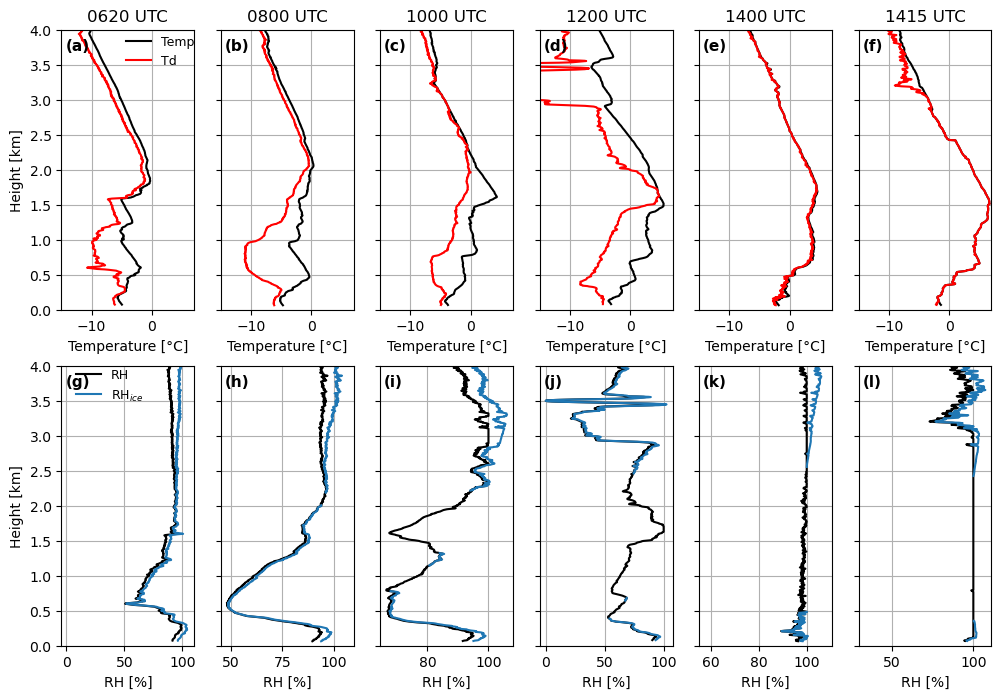

In [11]:
fig,axs= plt.subplots(2,len(file_soundings),figsize=(12,8))

ax = axs[0,:]

ind_first = 10

for i in range(len(file_soundings)):
    ax[i].plot(dfs_sounding[i].Temp[ind_first:],dfs_sounding[i].height[ind_first:]/1000.,color='k')
    to_plot = np.array([kin1d_functions.dewpoint_from_rh(dfs_sounding[i].iloc[j].Temp+273.15,dfs_sounding[i].iloc[j].RelHum/100.,) for j in range(len(dfs_sounding[i].Temp)) ])
    ax[i].plot(to_plot[ind_first:] - 273.15,dfs_sounding[i].height[ind_first:]/1000.,color='red')

ax[0].plot(1,1,color='k',label='Temp')
ax[0].plot(1,1,color='red',label='Td')

ax[0].legend(frameon=False,bbox_to_anchor=(0.4, 1.02), fontsize=9)


for i in np.arange(1,len(file_soundings)):
    ax[i].set_yticklabels(['','','','','','','','','','',''])
    ax[i].set_ylabel('')
    
titles = ['0620 UTC','0800 UTC','1000 UTC','1200 UTC','1400 UTC','1415 UTC','1440 UTC','1600 UTC']
for i in range(len(file_soundings)):
    ax[i].set_ylim([0,4])
    ax[i].set_xlim([-15,7])
    ax[i].grid('on')
    ax[i].set_xlabel('Temperature [°C]')
    
    ax[i].set_title(titles[i])
    
ax[0].set_ylabel('Height [km]')



ax2 = axs[1,:]
for i in range(len(file_soundings)):
    ax2[i].plot(dfs_sounding[i].RelHum[ind_first:],dfs_sounding[i].height[ind_first:]/1000.,color='k')
    to_plot = np.array([100.*kin1d_functions.rh_to_ice(dfs_sounding[i].iloc[j].RelHum/100., dfs_sounding[i].iloc[j].Temp+273.15) for j in range(len(dfs_sounding[i].Temp)) ])
    ax2[i].plot(to_plot[ind_first:],dfs_sounding[i].height[ind_first:]/1000.,color='C0')

ax2[0].plot(1,1,color='k',label='RH')
ax2[0].plot(1,1,color='C0',label=r'RH$_{ice}$')

ax2[0].legend(frameon=False,bbox_to_anchor=(0.7, 1.03), fontsize=9,loc='upper right')





for i in np.arange(1,len(file_soundings)):
    ax2[i].set_yticklabels(['','','','','','','','','','',''])
    ax2[i].set_ylabel('')
    
titles = ['2000 UTC','2200 UTC','0000 UTC','0200 UTC','0420 UTC']
for i in range(len(file_soundings)):
    ax2[i].set_ylim([0,4])
    # ax2[i].set_xlim([-15,7])
    ax2[i].grid('on')
    ax2[i].set_xlabel('RH [%]')
    
    # ax2[i].set_title(titles[i])
    
ax2[0].set_ylabel('Height [km]')


for n, axi in enumerate(axs.flatten()):
    axi.text(
        0.03, 0.97, f'({chr(97 + n)})',
        transform=axi.transAxes,
        ha='left', va='top',
        fontsize=11, fontweight='bold'
    )
    
plt.savefig('../figures/figures_soundings_iop8_sorel.png',format='png',bbox_inches='tight',dpi=300)


# IOP5 Trois-Rivieres

In [12]:
file_soundings = ['upperair.sounding.202202222200.UQAM-Trois-Rivieres.txt',
                  'upperair.sounding.202202230000.UQAM-Trois-Rivieres.txt',
                  # 'upperair.sounding.202202230200.UQAM-Trois-Rivieres.txt',
                  'upperair.sounding.202202230400.UQAM-Trois-Rivieres.txt'
                  ]


path = '/home/rml000/sitestore8/UQAM/projet_margaux/Pour_Mathieu_fig4/soundings_wintremix/'
dfs_sounding = []
for file in file_soundings:
    print(file)
    dfs_sounding.append(get_manobs_soundings_pr_df.read_soundings_data(path + file)[:1000])



upperair.sounding.202202222200.UQAM-Trois-Rivieres.txt
upperair.sounding.202202230000.UQAM-Trois-Rivieres.txt
upperair.sounding.202202230400.UQAM-Trois-Rivieres.txt


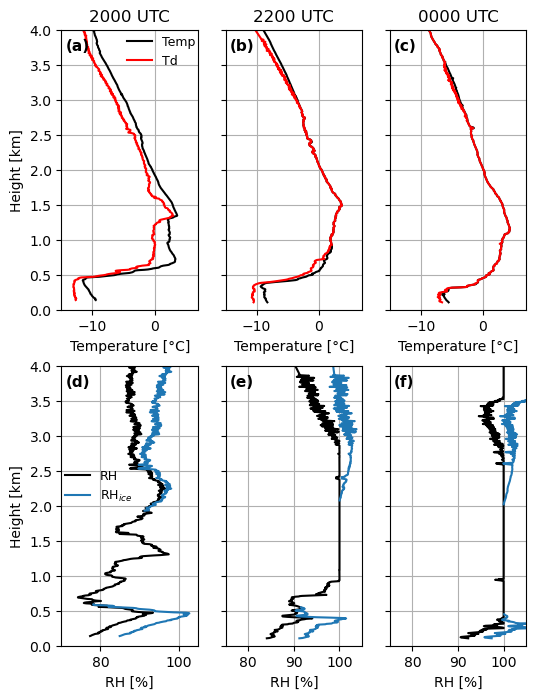

In [13]:
fig,axs= plt.subplots(2,3,figsize=(6,8))

ax = axs[0,:]

ind_first = 10

for i in range(3):
    ax[i].plot(dfs_sounding[i].Temp[ind_first:],dfs_sounding[i].height[ind_first:]/1000.,color='k')
    to_plot = np.array([kin1d_functions.dewpoint_from_rh(dfs_sounding[i].iloc[j].Temp+273.15,dfs_sounding[i].iloc[j].RelHum/100.,) for j in range(len(dfs_sounding[i].Temp)) ])
    ax[i].plot(to_plot[ind_first:] - 273.15,dfs_sounding[i].height[ind_first:]/1000.,color='red')

ax[0].plot(1,1,color='k',label='Temp')
ax[0].plot(1,1,color='red',label='Td')

ax[0].legend(frameon=False,bbox_to_anchor=(0.4, 1.02), fontsize=9)


for i in np.arange(1,3):
    ax[i].set_yticklabels(['','','','','','','','','','',''])
    ax[i].set_ylabel('')
    
titles = ['2000 UTC','2200 UTC','0000 UTC','0200 UTC','0420 UTC']
for i in range(3):
    ax[i].set_ylim([0,4])
    ax[i].set_xlim([-15,7])
    ax[i].grid('on')
    ax[i].set_xlabel('Temperature [°C]')
    
    ax[i].set_title(titles[i])
    
ax[0].set_ylabel('Height [km]')



ax2 = axs[1,:]
for i in range(3):
    ax2[i].plot(dfs_sounding[i].RelHum[ind_first:],dfs_sounding[i].height[ind_first:]/1000.,color='k')
    to_plot = np.array([100.*kin1d_functions.rh_to_ice(dfs_sounding[i].iloc[j].RelHum/100., dfs_sounding[i].iloc[j].Temp+273.15) for j in range(len(dfs_sounding[i].Temp)) ])
    ax2[i].plot(to_plot[ind_first:],dfs_sounding[i].height[ind_first:]/1000.,color='C0')

ax2[0].plot(1,1,color='k',label='RH')
ax2[0].plot(1,1,color='C0',label=r'RH$_{ice}$')

ax2[0].legend(frameon=False,bbox_to_anchor=(0.6, 0.67), fontsize=9,loc='upper right')


ax2[0].set_xlim([70,105])
ax2[1].set_xlim([75,105])
ax2[2].set_xlim([75,105])



for i in np.arange(1,3):
    ax2[i].set_yticklabels(['','','','','','','','','','',''])
    ax2[i].set_ylabel('')
    
titles = ['2000 UTC','2200 UTC','0000 UTC','0200 UTC','0420 UTC']
for i in range(3):
    ax2[i].set_ylim([0,4])
    # ax2[i].set_xlim([-15,7])
    ax2[i].grid('on')
    ax2[i].set_xlabel('RH [%]')
    
    # ax2[i].set_title(titles[i])
    
ax2[0].set_ylabel('Height [km]')


for n, axi in enumerate(axs.flatten()):
    axi.text(
        0.03, 0.97, f'({chr(97 + n)})',
        transform=axi.transAxes,
        ha='left', va='top',
        fontsize=11, fontweight='bold'
    )
    
plt.savefig('../figures/figures_soundings_iop5_trois.png',format='png',bbox_inches='tight',dpi=300)


# IOP4 CU-DOW

In [14]:
file_soundings = ['upperair.sounding.202202180100.CU_DOW-CAN_S.csv',
                  'upperair.sounding.202202180300.CU_DOW-CAN_S.csv',
                  'upperair.sounding.202202180500.CU_DOW-CAN_S.csv',
                  'upperair.sounding.202202180700.CU_DOW-CAN_S.csv']


path = 'soundings_wintremix/'
dfs_sounding = []
for file in file_soundings:
    print(file)
    dfs_sounding.append(get_manobs_soundings_pr_df.read_soundings_data(path + file)[:1000])

# dfs_sounding[4].loc[:,'RelHum'] = np.minimum(dfs_sounding[4].loc[:,'RelHum']+(100.-dfs_sounding[4].loc[200:400,'RelHum'].mean()), 100.)


upperair.sounding.202202180100.CU_DOW-CAN_S.csv
upperair.sounding.202202180300.CU_DOW-CAN_S.csv
upperair.sounding.202202180500.CU_DOW-CAN_S.csv
upperair.sounding.202202180700.CU_DOW-CAN_S.csv


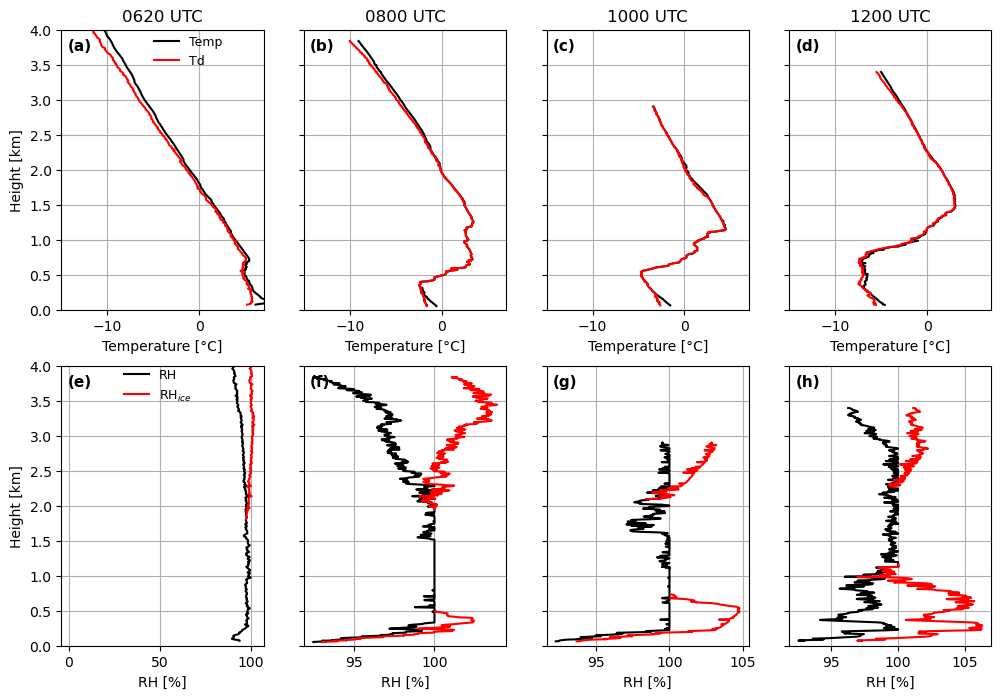

In [15]:
fig,axs= plt.subplots(2,len(file_soundings),figsize=(12,8))

ax = axs[0,:]

ind_first = 10

for i in range(len(file_soundings)):
    ax[i].plot(dfs_sounding[i].Temp[ind_first:],dfs_sounding[i].height[ind_first:]/1000.,color='k')
    to_plot = np.array([kin1d_functions.dewpoint_from_rh(dfs_sounding[i].iloc[j].Temp+273.15,dfs_sounding[i].iloc[j].RelHum/100.,) for j in range(len(dfs_sounding[i].Temp)) ])
    ax[i].plot(to_plot[ind_first:] - 273.15,dfs_sounding[i].height[ind_first:]/1000.,color='red')

ax[0].plot(1,1,color='k',label='Temp')
ax[0].plot(1,1,color='red',label='Td')

ax[0].legend(frameon=False,bbox_to_anchor=(0.4, 1.02), fontsize=9)


for i in np.arange(1,len(file_soundings)):
    ax[i].set_yticklabels(['','','','','','','','','','',''])
    ax[i].set_ylabel('')
    
titles = ['0620 UTC','0800 UTC','1000 UTC','1200 UTC','1400 UTC','1415 UTC','1440 UTC','1600 UTC']
for i in range(len(file_soundings)):
    ax[i].set_ylim([0,4])
    ax[i].set_xlim([-15,7])
    ax[i].grid('on')
    ax[i].set_xlabel('Temperature [°C]')
    
    ax[i].set_title(titles[i])
    
ax[0].set_ylabel('Height [km]')



ax2 = axs[1,:]
for i in range(len(file_soundings)):
    ax2[i].plot(dfs_sounding[i].RelHum[ind_first:],dfs_sounding[i].height[ind_first:]/1000.,color='k')
    to_plot = np.array([100.*kin1d_functions.rh_to_ice(dfs_sounding[i].iloc[j].RelHum/100., dfs_sounding[i].iloc[j].Temp+273.15) for j in range(len(dfs_sounding[i].Temp)) ])
    ax2[i].plot(to_plot[ind_first:],dfs_sounding[i].height[ind_first:]/1000.,color='red')

ax2[0].plot(1,1,color='k',label='RH')
ax2[0].plot(1,1,color='red',label=r'RH$_{ice}$')

ax2[0].legend(frameon=False,bbox_to_anchor=(0.7, 1.03), fontsize=9,loc='upper right')





for i in np.arange(1,len(file_soundings)):
    ax2[i].set_yticklabels(['','','','','','','','','','',''])
    ax2[i].set_ylabel('')
    
titles = ['2000 UTC','2200 UTC','0000 UTC','0200 UTC','0420 UTC']
for i in range(len(file_soundings)):
    ax2[i].set_ylim([0,4])
    # ax2[i].set_xlim([-15,7])
    ax2[i].grid('on')
    ax2[i].set_xlabel('RH [%]')
    
    # ax2[i].set_title(titles[i])
    
ax2[0].set_ylabel('Height [km]')


for n, axi in enumerate(axs.flatten()):
    axi.text(
        0.03, 0.97, f'({chr(97 + n)})',
        transform=axi.transAxes,
        ha='left', va='top',
        fontsize=11, fontweight='bold'
    )
    
